<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    NLP Triagem Inteligente Financeira - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Deployment & Monitoring | Baseline API Readiness
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Preparar o baseline selecionado para um cenário inicial de deployment, estruturando inferência reutilizável,<br />logging de predições e indicadores básicos de monitoramento operacional.
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- **Ações realizadas neste notebook**
    - ***Leitura do pipeline baseline salvo***
    - ***Leitura do mapping de labels***
    - ***Simulação de inferência local***
    - ***Estruturação do contrato de entrada e saída***
    - ***Registro de logs de predição***
    - ***Criação de métricas iniciais de monitoramento***
    - ***Preparação da transição para API REST com FastAPI***

>- **Justificativa técnica**
    - Um modelo não está pronto para uso apenas porque foi treinado.
    - É necessário garantir que ele possa ser carregado, receber entrada padronizada, retornar saídas consistentes e registrar evidências mínimas de uso em produção.

>- **Resultados esperados**
    - Pipeline baseline carregado com sucesso
    - Função de inferência pronta
    - Saída estruturada para API
    - Log inicial de predições persistido
    - Métricas simples de monitoramento disponíveis

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leitura executiva da etapa</strong></font>

<font size="2" color='#66666'>

>- Este notebook representa a passagem do projeto de **modelagem** para **uso operacional inicial**.

>- A decisão técnica levada para esta etapa foi:
    - **Deployment inicial com o baseline TF-IDF + Logistic Regression**

>- A escolha foi orientada por evidência, priorizando:
    - melhor desempenho observado
    - maior simplicidade operacional
    - menor custo de serving
    - maior previsibilidade para um primeiro deployment

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 1 — Setup do ambiente e leitura dos artefatos de deployment</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Carregar os artefatos necessários para a etapa de inferência e monitoramento inicial.

>- **Ações realizadas**
    - ***Importação das bibliotecas***
    - ***Definição dos diretórios do projeto***
    - ***Leitura do pipeline baseline salvo***
    - ***Leitura do label mapping***
    - ***Preparação das pastas de logs e saídas***

>- **Justificativa técnica**
    - A etapa de deployment precisa começar com uma base explícita e reproduzível, garantindo que o modelo salvo possa ser reutilizado sem retrabalho.

>- **Resultados esperados**
    - Ambiente pronto para inferência
    - Pipeline baseline carregado
    - Mapping de labels carregado
    - Estrutura de logs criada

</font></div>

In [19]:
from pathlib import Path
import json
from datetime import datetime, timezone
import uuid

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

DATA_DIR = PROJECT_ROOT / "data"
GOLD_DIR = DATA_DIR / "03-gold"

MODELS_DIR = PROJECT_ROOT / "models"
BASELINE_MODELS_DIR = MODELS_DIR / "baseline"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
LOGS_DIR = ARTIFACTS_DIR / "logs"
INFERENCE_DIR = DATA_DIR / "04-inference"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT        :", PROJECT_ROOT)
print("BASELINE_MODELS_DIR :", BASELINE_MODELS_DIR)
print("REPORTS_DIR         :", REPORTS_DIR)
print("LOGS_DIR            :", LOGS_DIR)
print("INFERENCE_DIR       :", INFERENCE_DIR)


PROJECT_ROOT        : D:\_DS-Projects\nlp-triagem-inteligente-financeira
BASELINE_MODELS_DIR : D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\baseline
REPORTS_DIR         : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports
LOGS_DIR            : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\logs
INFERENCE_DIR       : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\04-inference


In [4]:
model_path = BASELINE_MODELS_DIR / "tfidf_logreg_pipeline.joblib"
label_mapping_path = GOLD_DIR / "label_mapping.csv"
baseline_metadata_path = BASELINE_MODELS_DIR / "baseline_metadata.json"

baseline_model = joblib.load(model_path)
label_mapping_df = pd.read_csv(label_mapping_path)

with open(baseline_metadata_path, "r", encoding="utf-8") as f:
    baseline_metadata = json.load(f)

print("Modelo carregado com sucesso.")
print("Shape label_mapping_df:", label_mapping_df.shape)
print("Selected model name:", baseline_metadata["selected_model_name"])


Modelo carregado com sucesso.
Shape label_mapping_df: (242, 2)
Selected model name: tfidf_word_unigram_logreg


In [5]:
id_to_label = dict(zip(label_mapping_df["label_id"], label_mapping_df["category_final"]))
label_to_id = dict(zip(label_mapping_df["category_final"], label_mapping_df["label_id"]))

print("Número de labels:", len(id_to_label))
print("Primeiras labels:", list(id_to_label.items())[:10])

Número de labels: 242
Primeiras labels: [(0, 'Acordo Administrativo em Processo de Supervisão (APS)'), (1, 'Alerta contra golpes envolvendo o nome do Banco Central e de instituições financeiras'), (2, 'Aplicações financeiras'), (3, 'Arranjos de Pagamentos Compras e relações de consumo'), (4, 'Arranjos de Pagamentos Conceitos importantes'), (5, 'Arranjos de Pagamentos Informações Gerais'), (6, 'Arranjos de Pagamentos Interoperabilidade, liquidação centralizada e compulsório'), (7, 'Arranjos de Pagamentos Supervisão dos arranjos pelo BC'), (8, 'Atendimento bancário (fila, feriados e outros)'), (9, 'Bacen Jud e SISBAJUD Informações gerais')]


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- O pipeline carregado aqui já encapsula:
    - vetorização TF-IDF
    - classificador de Regressão Logística

>- Isso é importante porque simplifica o deployment: a inferência passa a depender de um único artefato serializado.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 2 — Contrato de entrada e saída da inferência</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Definir explicitamente o formato esperado de entrada e o formato produzido como saída da inferência.

>- **Ações realizadas**
    - ***Definição do payload mínimo***
    - ***Definição dos campos de retorno***
    - ***Registro da lógica de uso operacional***

>- **Justificativa técnica**
    - Deployment confiável exige contrato claro de entrada e saída.
    - Isso reduz ambiguidade na integração com API, frontend ou sistemas externos.

>- **Resultados esperados**
    - Estrutura mínima de entrada definida
    - Estrutura mínima de saída definida
    - Base para integração com FastAPI

</font></div>

In [6]:
sample_request_contract = {
    "request_id": "uuid-gerado-no-serving",
    "text": "Não reconheço uma compra no meu cartão de crédito.",
    "source_channel": "app",
    "request_timestamp": "2026-01-01T12:00:00"
}

sample_response_contract = {
    "request_id": "uuid-gerado-no-serving",
    "predicted_label": "categoria prevista",
    "predicted_label_id": 0,
    "model_name": baseline_metadata["selected_model_name"],
    "model_family": baseline_metadata["model_family"],
    "inference_timestamp": "2026-01-01T12:00:01"
}

sample_request_contract, sample_response_contract


({'request_id': 'uuid-gerado-no-serving',
  'text': 'Não reconheço uma compra no meu cartão de crédito.',
  'source_channel': 'app',
  'request_timestamp': '2026-01-01T12:00:00'},
 {'request_id': 'uuid-gerado-no-serving',
  'predicted_label': 'categoria prevista',
  'predicted_label_id': 0,
  'model_name': 'tfidf_word_unigram_logreg',
  'model_family': 'TF-IDF + Logistic Regression',
  'inference_timestamp': '2026-01-01T12:00:01'})

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leitura prática do contrato</strong></font>

<font size="2" color='#66666'>

>- **Entrada mínima**
    - *`text`: texto da demanda*
    - *`source_channel`: canal de origem*
    - *`request_timestamp`: momento da requisição*
    - *`request_id`: identificador único*

>- **Saída mínima**
    - *categoria prevista*
    - *id da categoria*
    - *identificação do modelo*
    - *timestamp da inferência*

>- Nesta primeira versão, a API será pensada para classificação simples de uma demanda por vez.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 3 — Função de inferência local</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Criar uma função de inferência reutilizável para uso local e posterior adaptação para a API.

>- **Ações realizadas**
    - ***Padronização do input textual***
    - ***Execução da predição com o pipeline salvo***
    - ***Mapeamento do label numérico para o nome da categoria***
    - ***Montagem do dicionário de resposta***

>- **Justificativa técnica**
    - Separar a lógica de inferência em função explícita facilita testes, logging e integração com o endpoint da API.

>- **Resultados esperados**
    - Função de inferência pronta
    - Saída padronizada e consistente

</font></div>

In [20]:
def normalize_input_text(text: str) -> str:
    return str(text).strip()


def predict_single_text(
    text: str,
    model,
    metadata: dict,
    id_to_label_map: dict,
    source_channel: str = "unknown",
) -> dict:
    request_id = str(uuid.uuid4())
    request_timestamp = datetime.now(timezone.utc).isoformat()
    inference_timestamp = datetime.now(timezone.utc).isoformat()

    text_prepared = normalize_input_text(text)

    pred_label_id = int(model.predict([text_prepared])[0])
    pred_label = id_to_label_map[pred_label_id]

    return {
        "request_id": request_id,
        "text": text_prepared,
        "source_channel": source_channel,
        "request_timestamp": request_timestamp,
        "predicted_label": pred_label,
        "predicted_label_id": pred_label_id,
        "model_name": metadata["selected_model_name"],
        "model_family": metadata["model_family"],
        "inference_timestamp": inference_timestamp,
    }
    

In [21]:
test_prediction = predict_single_text(
    text="Não reconheço uma transação feita no meu cartão.",
    model=baseline_model,
    metadata=baseline_metadata,
    id_to_label_map=id_to_label,
    source_channel="app",
)

test_prediction


{'request_id': 'a2c5470c-fa6a-4513-8aae-cf28cb2a495e',
 'text': 'Não reconheço uma transação feita no meu cartão.',
 'source_channel': 'app',
 'request_timestamp': '2026-04-18T17:21:39.843543+00:00',
 'predicted_label': 'Cooperativas de crédito Capitalização e sobras',
 'predicted_label_id': 80,
 'model_name': 'tfidf_word_unigram_logreg',
 'model_family': 'TF-IDF + Logistic Regression',
 'inference_timestamp': '2026-04-18T17:21:39.843543+00:00'}

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leitura prática do contrato</strong></font>

<font size="2" color='#66666'>

>- Esta primeira função de inferência retorna apenas a classe prevista.  

>- Para um MVP operacional de triagem, isso já é suficiente para demonstrar:
    - uso prático do modelo salvo
    - padronização da resposta
    - preparação para serving em API REST

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 4 — Simulação de inferência em lote</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Simular um pequeno fluxo operacional de inferência sobre múltiplas demandas.

>- **Ações realizadas**
    - ***Criação de exemplos de entrada***
    - ***Execução da inferência em lote***
    - ***Consolidação dos resultados em DataFrame***

>- **Justificativa técnica**
    - Mesmo quando a API opera caso a caso, testes em lote ajudam a validar consistência, logging e visão agregada de uso.

>- **Resultados esperados**
    - Lote de inferência processado
    - Saídas organizadas em DataFrame
    - Base inicial para logging

</font></div>

In [22]:
sample_texts = [
    {"text": "Quero entender uma cobrança na minha fatura do cartão.", "source_channel": "app"},
    {"text": "Não reconheço uma transferência realizada da minha conta.", "source_channel": "chat"},
    {"text": "Como funciona a portabilidade de crédito?", "source_channel": "web"},
    {"text": "Quais são as tarifas do Pix?", "source_channel": "app"},
    {"text": "Desejo cancelar meu cartão de crédito.", "source_channel": "call_center"},
]

sample_texts_df = pd.DataFrame(sample_texts)
sample_texts_df

,text,source_channel
0,Quero entender uma cobrança na minha fatura do cartão.,app
1,Não reconheço uma transferência realizada da minha conta.,chat
2,Como funciona a portabilidade de crédito?,web
3,Quais são as tarifas do Pix?,app
4,Desejo cancelar meu cartão de crédito.,call_center


In [23]:
batch_predictions = [
    predict_single_text(
        text=row["text"],
        model=baseline_model,
        metadata=baseline_metadata,
        id_to_label_map=id_to_label,
        source_channel=row["source_channel"],
    )
    for _, row in sample_texts_df.iterrows()
]

batch_predictions_df = pd.DataFrame(batch_predictions)
batch_predictions_df


,request_id,text,source_channel,request_timestamp,predicted_label,predicted_label_id,model_name,model_family,inference_timestamp
0,4e70253f-ea97-461f-b013-d3929be5e328,Quero entender uma cobrança na minha fatura do cartão.,app,2026-04-18T17:21:48.097038+00:00,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,71,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.097038+00:00
1,22648b65-2926-477e-92e4-9f974f6d6b28,Não reconheço uma transferência realizada da minha conta.,chat,2026-04-18T17:21:48.099041+00:00,Contas de depósitos (conta corrente e conta poupança) Encerramento,76,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.099041+00:00
2,7a7bda22-7a24-4a81-b3bb-152375799026,Como funciona a portabilidade de crédito?,web,2026-04-18T17:21:48.103042+00:00,Portabilidade de Crédito Recomendações,177,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.103042+00:00
3,781e6f2a-899a-49ba-863d-2eea82806047,Quais são as tarifas do Pix?,app,2026-04-18T17:21:48.105041+00:00,Pagamento Instantâneo (Pix) Entendendo como funciona o Pix,161,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.105041+00:00
4,b7413b71-50b0-48cf-b38e-69cbe8d516ac,Desejo cancelar meu cartão de crédito.,call_center,2026-04-18T17:21:48.108039+00:00,Open Banking Consentimento para compartilhamento,149,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.108039+00:00


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 5 — Logging de predições</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Registrar as predições realizadas em uma estrutura persistente simples para auditoria e monitoramento inicial.

>- **Ações realizadas**
    - ***Definição do schema de log***
    - ***Salvamento das predições em CSV***
    - ***Releitura do log consolidado***

>- **Justificativa técnica**
    - Mesmo em um MVP, registrar evidências de inferência é importante para rastreabilidade, análise posterior e governança mínima.

>- **Resultados esperados**
    - Log de predições persistido
    - Estrutura simples de auditoria disponível

</font></div>

In [24]:
prediction_log_path = LOGS_DIR / "prediction_log.csv"

if prediction_log_path.exists():
    existing_log_df = pd.read_csv(prediction_log_path)
else:
    existing_log_df = pd.DataFrame()

existing_log_df.shape


(0, 0)

In [25]:
updated_log_df = pd.concat([existing_log_df, batch_predictions_df], ignore_index=True)
updated_log_df.to_csv(prediction_log_path, index=False)

print("Log salvo em:", prediction_log_path)
print("Shape do log atualizado:", updated_log_df.shape)

Log salvo em: D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\logs\prediction_log.csv
Shape do log atualizado: (5, 9)


In [26]:
prediction_log_df = pd.read_csv(prediction_log_path)
prediction_log_df.tail(10)

,request_id,text,source_channel,request_timestamp,predicted_label,predicted_label_id,model_name,model_family,inference_timestamp
0,4e70253f-ea97-461f-b013-d3929be5e328,Quero entender uma cobrança na minha fatura do cartão.,app,2026-04-18T17:21:48.097038+00:00,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,71,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.097038+00:00
1,22648b65-2926-477e-92e4-9f974f6d6b28,Não reconheço uma transferência realizada da minha conta.,chat,2026-04-18T17:21:48.099041+00:00,Contas de depósitos (conta corrente e conta poupança) Encerramento,76,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.099041+00:00
2,7a7bda22-7a24-4a81-b3bb-152375799026,Como funciona a portabilidade de crédito?,web,2026-04-18T17:21:48.103042+00:00,Portabilidade de Crédito Recomendações,177,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.103042+00:00
3,781e6f2a-899a-49ba-863d-2eea82806047,Quais são as tarifas do Pix?,app,2026-04-18T17:21:48.105041+00:00,Pagamento Instantâneo (Pix) Entendendo como funciona o Pix,161,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.105041+00:00
4,b7413b71-50b0-48cf-b38e-69cbe8d516ac,Desejo cancelar meu cartão de crédito.,call_center,2026-04-18T17:21:48.108039+00:00,Open Banking Consentimento para compartilhamento,149,tfidf_word_unigram_logreg,TF-IDF + Logistic Regression,2026-04-18T17:21:48.108039+00:00


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- Neste projeto, o logging foi mantido simples e explícito:
    - um registro por inferência
    - identificação do request
    - texto de entrada
    - canal de origem
    - categoria prevista
    - metadados do modelo

>- Em um ambiente produtivo, essa camada poderia evoluir para banco transacional, mensageria ou observabilidade centralizada.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 6 — Monitoramento inicial de inferência</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Criar indicadores simples para acompanhar o comportamento das predições registradas.

>- **Ações realizadas**
    - ***Contagem de volume de inferências***
    - ***Distribuição das categorias previstas***
    - ***Distribuição por canal de origem***
    - ***Identificação de categorias dominantes***

>- **Justificativa técnica**
    - Monitoramento inicial ajuda a detectar comportamentos anômalos, concentração excessiva de classes e padrões de uso do modelo.

>- **Resultados esperados**
    - Indicadores operacionais básicos
    - Primeira visão de distribuição das predições
    - Base para futura monitoração em produção

</font></div>

In [27]:
monitoring_summary = {
    "n_predictions_logged": int(prediction_log_df.shape[0]),
    "n_unique_predicted_labels": int(prediction_log_df["predicted_label"].nunique()),
    "n_unique_source_channels": int(prediction_log_df["source_channel"].nunique()),
}

monitoring_summary

{'n_predictions_logged': 5,
 'n_unique_predicted_labels': 5,
 'n_unique_source_channels': 4}

In [28]:
predicted_label_distribution_df = (
    prediction_log_df["predicted_label"]
    .value_counts()
    .rename_axis("predicted_label")
    .reset_index(name="count")
)

predicted_label_distribution_df

,predicted_label,count
0,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,1
1,Contas de depósitos (conta corrente e conta poupança) Encerramento,1
2,Portabilidade de Crédito Recomendações,1
3,Pagamento Instantâneo (Pix) Entendendo como funciona o Pix,1
4,Open Banking Consentimento para compartilhamento,1


In [29]:
predicted_label_distribution_df = (
    prediction_log_df["predicted_label"]
    .value_counts()
    .rename_axis("predicted_label")
    .reset_index(name="count")
)

predicted_label_distribution_df

,predicted_label,count
0,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,1
1,Contas de depósitos (conta corrente e conta poupança) Encerramento,1
2,Portabilidade de Crédito Recomendações,1
3,Pagamento Instantâneo (Pix) Entendendo como funciona o Pix,1
4,Open Banking Consentimento para compartilhamento,1


In [30]:
source_channel_distribution_df = (
    prediction_log_df["source_channel"]
    .value_counts()
    .rename_axis("source_channel")
    .reset_index(name="count")
)

source_channel_distribution_df

,source_channel,count
0,app,2
1,chat,1
2,web,1
3,call_center,1


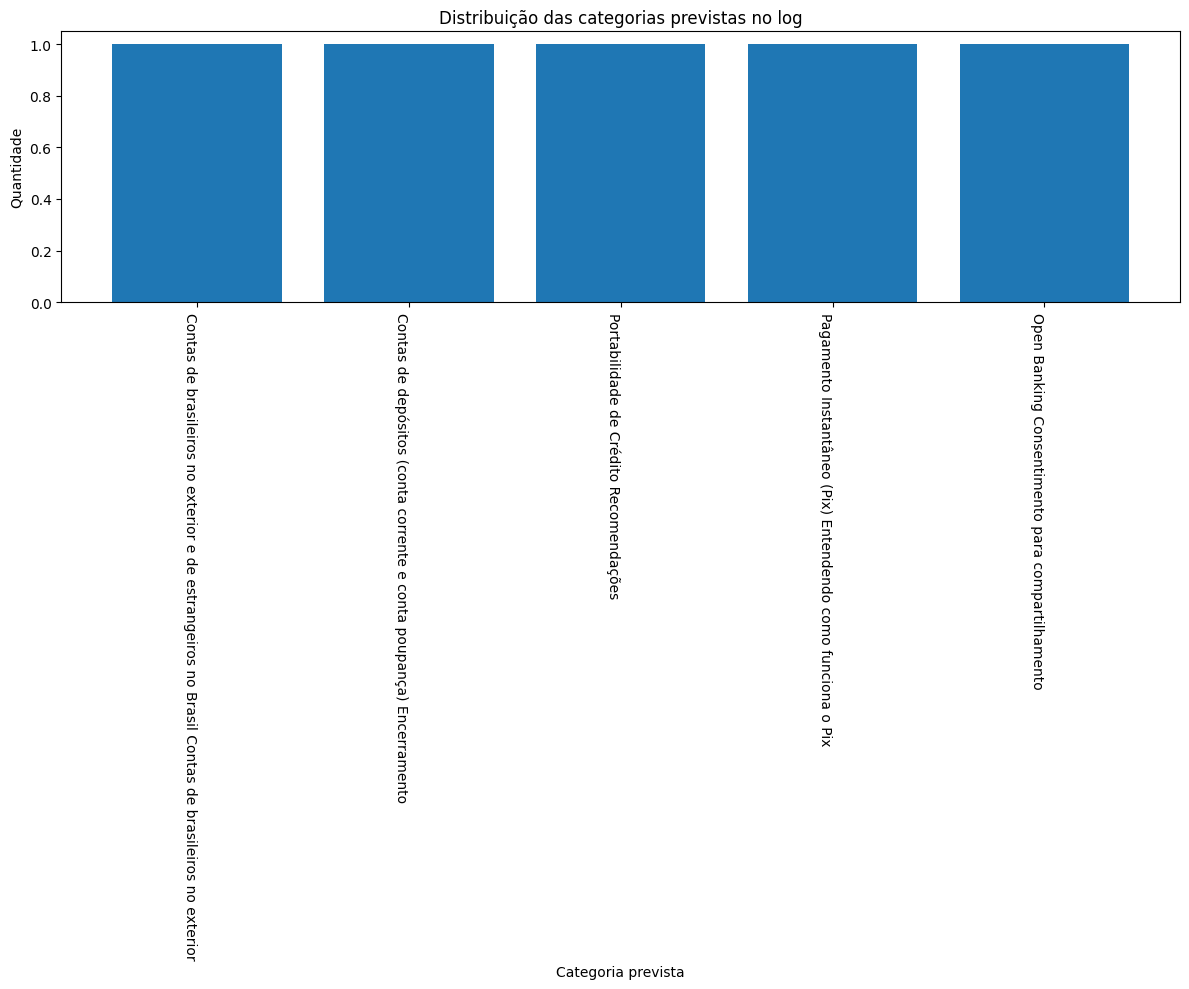

In [34]:
plt.figure(figsize=(12, 10))
plt.bar(predicted_label_distribution_df["predicted_label"], predicted_label_distribution_df["count"])
plt.title("Distribuição das categorias previstas no log")
plt.xlabel("Categoria prevista")
plt.ylabel("Quantidade")
plt.xticks(rotation=-90, ha="right")
plt.tight_layout()
plt.show()

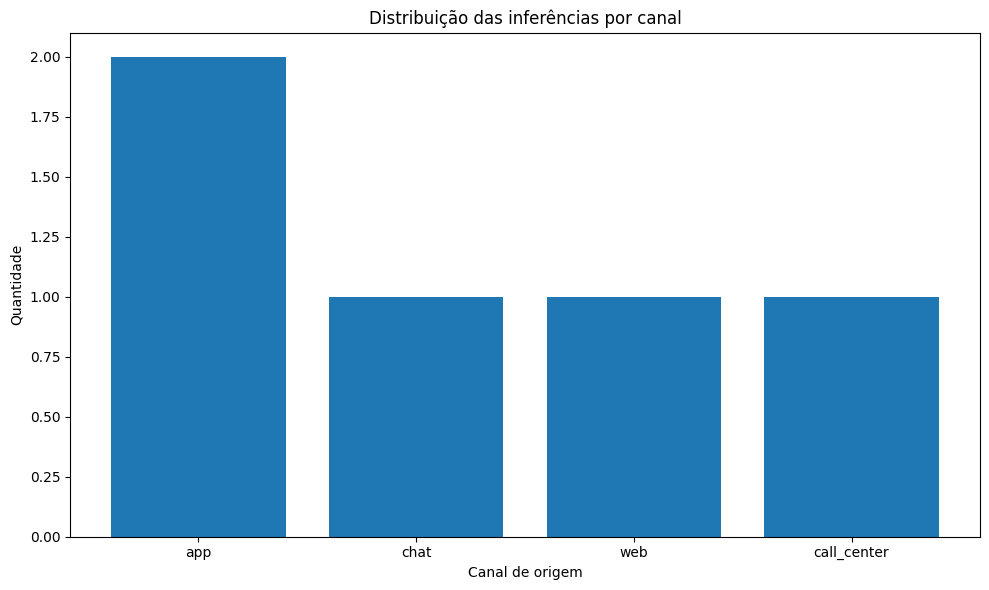

In [36]:
plt.figure(figsize=(10, 6))
plt.bar(source_channel_distribution_df["source_channel"], source_channel_distribution_df["count"])
plt.title("Distribuição das inferências por canal")
plt.xlabel("Canal de origem")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leituras iniciais de monitoramento</strong></font>

<font size="2" color='#66666'>

>- Nesta etapa, ainda não temos feedback real de acerto/erro em produção.  

>- Portanto, o monitoramento é focado em:
    - volume de inferência
    - dispersão ou concentração de categorias
    - uso por canal
    - rastreabilidade de requests

>- Em uma evolução futura, o ideal seria incluir:
    - truth delayed labels
    - monitoramento de drift
    - taxa de fallback humano
    - análise de erro pós-tratativa

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 7 — Preparação para API REST com FastAPI</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Formalizar a transição da inferência local para uma API REST simples e reprodutível.

>- **Ações realizadas**
    - ***Definição dos componentes mínimos da API***
    - ***Registro do endpoint esperado***
    - ***Padronização do fluxo de serving***

>- **Justificativa técnica**
    - Uma API REST torna o modelo integrável a aplicações, formulários, chatbots e fluxos de atendimento.

>- **Resultados esperados**
    - Desenho claro do serving inicial
    - Base para implementação em `src/api/`

</font></div>

In [37]:
api_contract_df = pd.DataFrame(
    [
        ["POST", "/predict", "Recebe um texto e retorna a categoria prevista"],
        ["GET", "/health", "Retorna status básico da aplicação"],
        ["GET", "/model-info", "Retorna metadados do modelo em uso"],
    ],
    columns=["method", "endpoint", "description"]
)

api_contract_df

,method,endpoint,description
0,POST,/predict,Recebe um texto e retorna a categoria prevista
1,GET,/health,Retorna status básico da aplicação
2,GET,/model-info,Retorna metadados do modelo em uso


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Fluxo esperado da API</strong></font>

<font size="2" color='#66666'>

>- **`/predict`**
    - ***1. recebe o payload com texto e metadados opcionais***  
    - ***2. normaliza a entrada***  
    - ***3. executa a predição com o pipeline carregado***  
    - ***4. registra a inferência no log***  
    - ***5. retorna a resposta estruturada***

>- **`/health`**
    - ***Retorna uma resposta simples de disponibilidade da aplicação.***

>- **`/model-info`**
    - ***Expõe metadados controlados do modelo em serving.***

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 8 — Persistência dos artefatos de deployment e monitoramento</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Salvar os principais artefatos gerados nesta etapa para reuso pela API e pela documentação do projeto.

>- **Ações realizadas**
    - ***Persistência do lote de inferência***
    - ***Persistência do log consolidado***
    - ***Persistência das tabelas de monitoramento***
    - ***Persistência do contrato da API***

>- **Justificativa técnica**
    - Persistir essas saídas fortalece reprodutibilidade, facilita testes e documenta a camada inicial de serving.

>- **Resultados esperados**
    - Artefatos de deployment salvos
    - Base pronta para implementação da API

</font></div>


In [38]:
batch_predictions_path = INFERENCE_DIR / "sample_batch_predictions.csv"
predicted_label_distribution_path = REPORTS_DIR / "monitoring_predicted_label_distribution.csv"
source_channel_distribution_path = REPORTS_DIR / "monitoring_source_channel_distribution.csv"
api_contract_path = REPORTS_DIR / "api_contract_table.csv"
monitoring_summary_path = REPORTS_DIR / "monitoring_summary.json"

batch_predictions_df.to_csv(batch_predictions_path, index=False)
prediction_log_df.to_csv(prediction_log_path, index=False)
predicted_label_distribution_df.to_csv(predicted_label_distribution_path, index=False)
source_channel_distribution_df.to_csv(source_channel_distribution_path, index=False)
api_contract_df.to_csv(api_contract_path, index=False)

with open(monitoring_summary_path, "w", encoding="utf-8") as f:
    json.dump(monitoring_summary, f, ensure_ascii=False, indent=2)

print("Artefatos salvos com sucesso:")
print(batch_predictions_path)
print(predicted_label_distribution_path)
print(source_channel_distribution_path)
print(api_contract_path)
print(monitoring_summary_path)


Artefatos salvos com sucesso:
D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\04-inference\sample_batch_predictions.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\monitoring_predicted_label_distribution.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\monitoring_source_channel_distribution.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\api_contract_table.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\monitoring_summary.json


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 9 — Leitura executiva do deployment inicial</strong></font>

<font size="2" color='#66666'>
    
> - **Síntese da etapa**
    - O baseline selecionado foi preparado para um deployment inicial orientado por simplicidade, rastreabilidade e reuso.

>- **O que esta etapa entrega**
    - pipeline carregável
    - inferência padronizada
    - contrato mínimo de entrada e saída
    - logging de predições
    - monitoramento inicial de uso
    - preparação objetiva para API REST

>- **Valor para o projeto**
    - Com esta etapa, o projeto passa a demonstrar:
        1. modelagem comparativa  
        2. decisão técnica orientada por evidência  
        3. readiness para deployment  
        4. preocupação com governança e monitoramento

</font></div>


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Próximo passo natural do projeto</strong></font>

<font size="2" color='#66666'>

>- A próxima evolução técnica pode seguir duas trilhas:

>- **Trilha A — API executável**
    - Implementar a API FastAPI em `src/api/main.py` com endpoints:
        - `/predict`
        - `/health`
        - `/model-info`

>- **Trilha B — evolução do experimento transformer**
    - Reformular o espaço de classes e repetir o experimento avançado com:
        - `question_raw`
        - redução de granularidade do target
        - agrupamento de classes raras

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>


In [39]:
#!uv pip install nbconvert -U -q
!jupyter nbconvert --to html --template-file my-template-html-v10.tpl 07_deployment__monitoring_baseline_api.ipynb

[NbConvertApp] Converting notebook 07_deployment__monitoring_baseline_api.ipynb to html
[NbConvertApp] Writing 166630 bytes to 07_deployment__monitoring_baseline_api.html
